In [2]:
from experiment_1 import *
from experiment_2 import *
from experiment_common_code import ExperimentResult, get_accuracy, plot_multiple_metrics
from common_constants import LANGUAGES, MODEL_NAMES, PROBING_TASKS
from icecream import ic

import torch as t
from itertools import permutations

from typing import Literal

device: Literal["cuda", "cpu"] = "cuda" if t.cuda.is_available() else "cpu"

# Experiment 1

ic| force_probe_creation: False, run_experiment: False


Plot saved to plots\Test_and_train_accuracies_by_layer_for_olmo_model_on_language_en.png


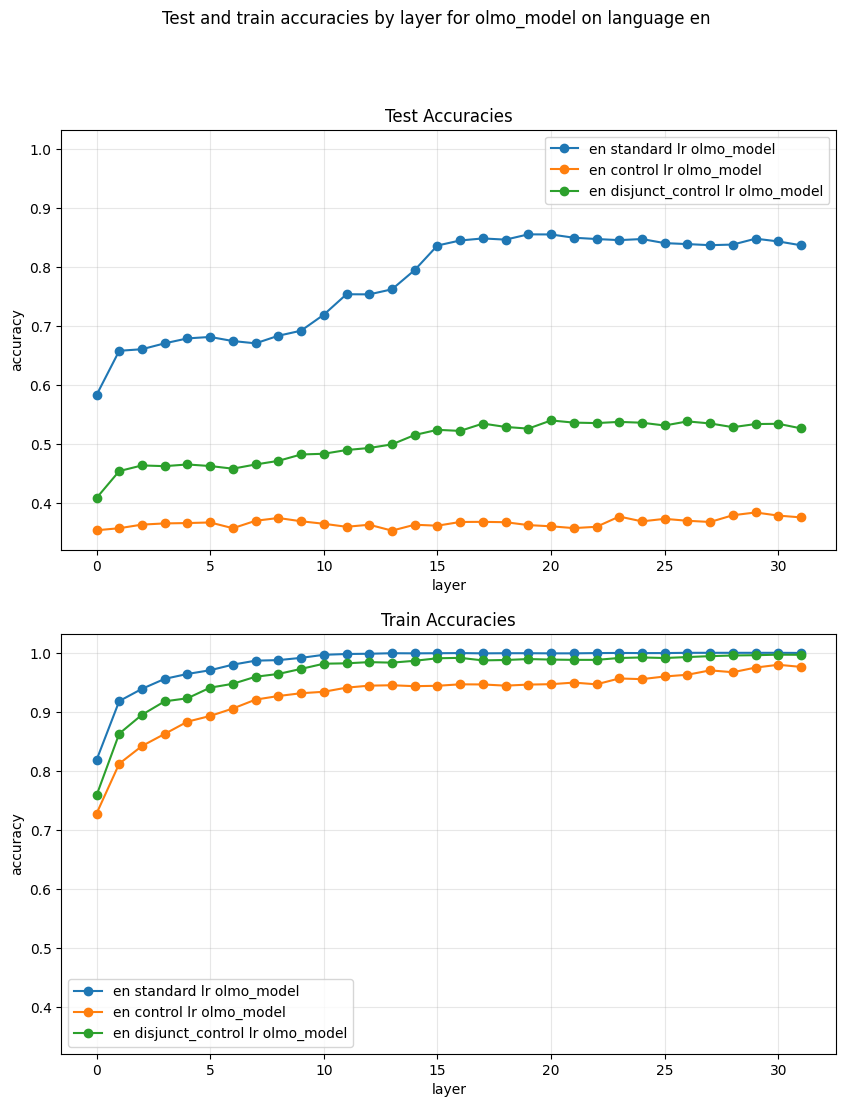

Plot saved to plots\Test_and_train_accuracies_by_layer_for_olmo_model_on_language_es.png


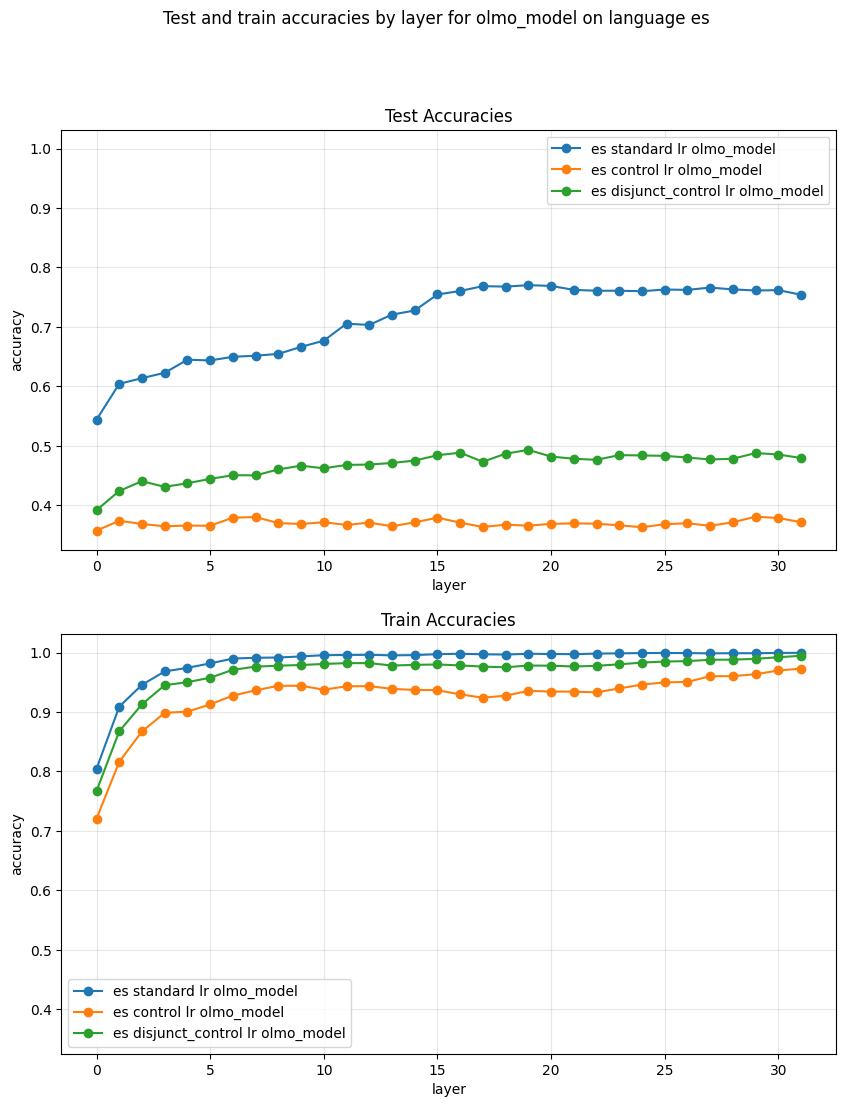

Plot saved to plots\Test_and_train_accuracies_by_layer_for_tiny_aya_global_on_language_en.png


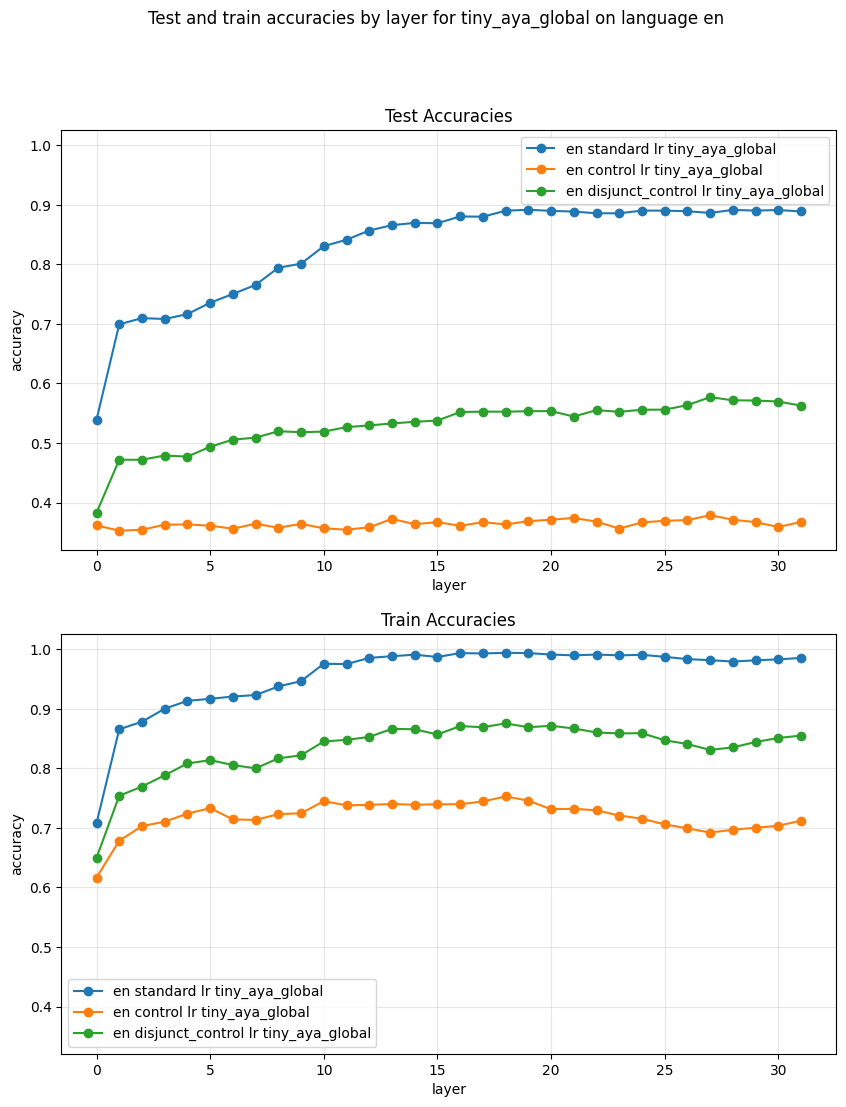

Plot saved to plots\Test_and_train_accuracies_by_layer_for_tiny_aya_global_on_language_es.png


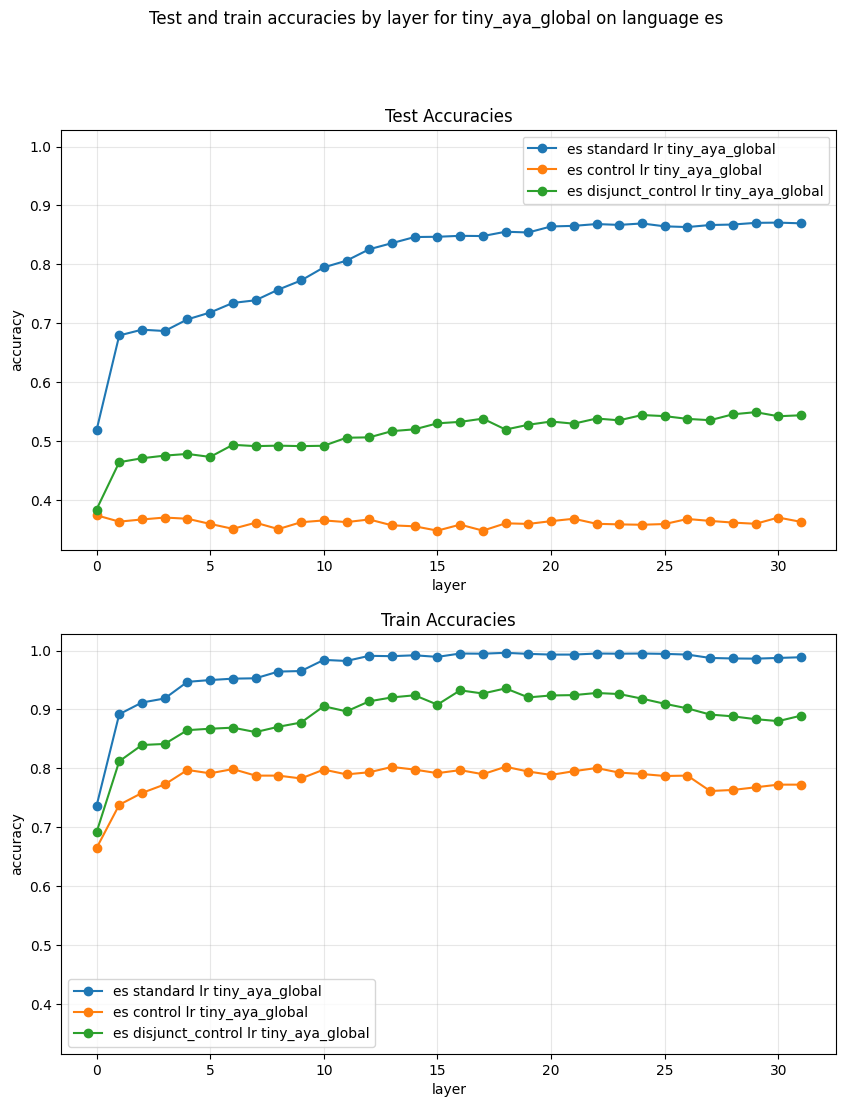

In [ ]:
experiment_number = 1

model_names: list[str] = MODEL_NAMES
languages: list[str] = LANGUAGES
probing_tasks: list[str] = PROBING_TASKS
probe_type: str = "lr"

custom = False
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probing_tasks = ["standard"]
    probe_type = "lr"
    print(f"Using custom configuration")
    ic(model_names, languages, probing_tasks, probe_type)

force_probe_creation: bool = False
run_experiment: bool = False

ic(force_probe_creation, run_experiment)

# If run_experiment, run the experiment and save the results as files.
if run_experiment:
    run_experiment_1(languages, probing_tasks, probe_type, model_names, force_probe_creation)

# Load the results from files
experiment_results_per_language: dict[str, list[ExperimentResult]] = {}

for model_name in model_names:
    for language in languages:
        experiment_results_per_language[language] = []
        for probing_task in probing_tasks:
            experiment_result: ExperimentResult = ExperimentResult.get_from_file(
                experiment_number, language, probing_task, probe_type, model_name
            )
            experiment_results_per_language[language].append(experiment_result)

        # Make some plots
        plot_multiple_metrics(
            experiment_results_per_language[language],
            ["test_accuracies", "train_accuracies"],
            f"Test and train accuracies by layer for {model_name} on language {language}",
            "layer",
            "accuracy",
            show=True,
            save=True,
        )

# Experiment 2

Using default settings
Plot saved to plots\Test_and_train_accuracies_by_layer_for_olmo_model_on_languages_en→es.png


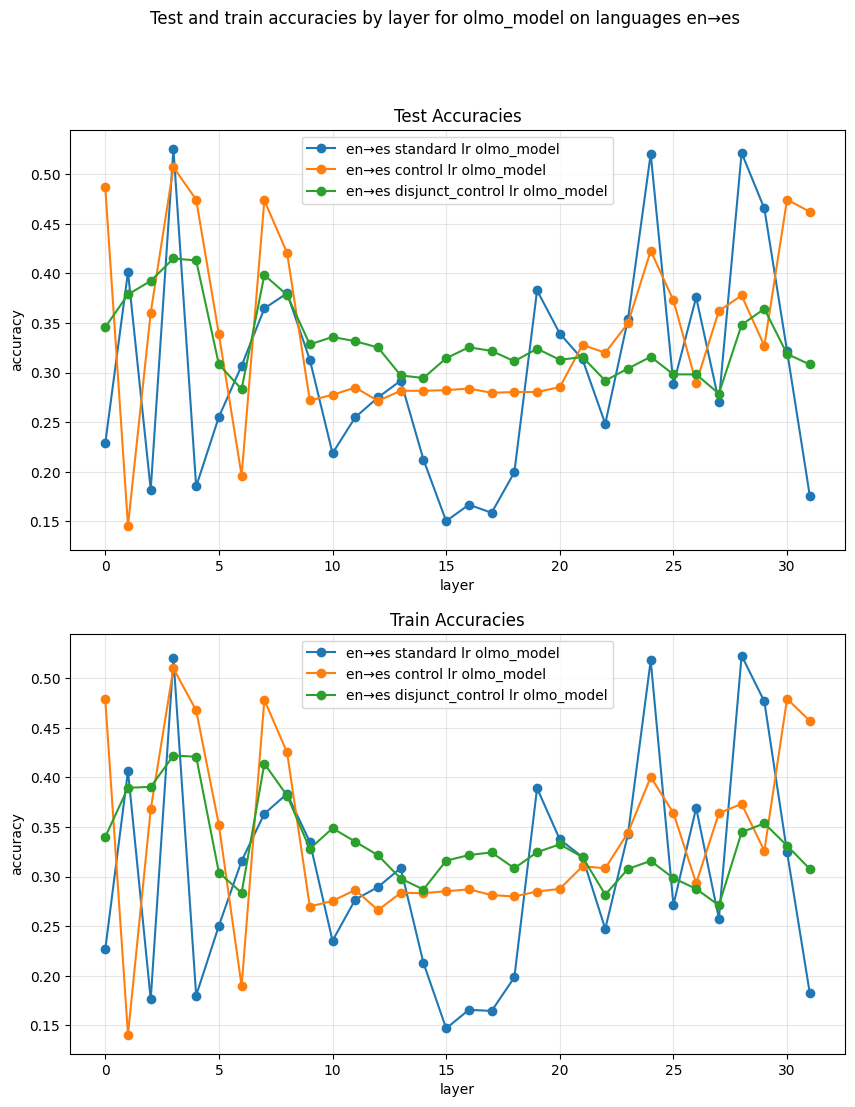

Plot saved to plots\Test_and_train_accuracies_by_layer_for_olmo_model_on_languages_es→en.png


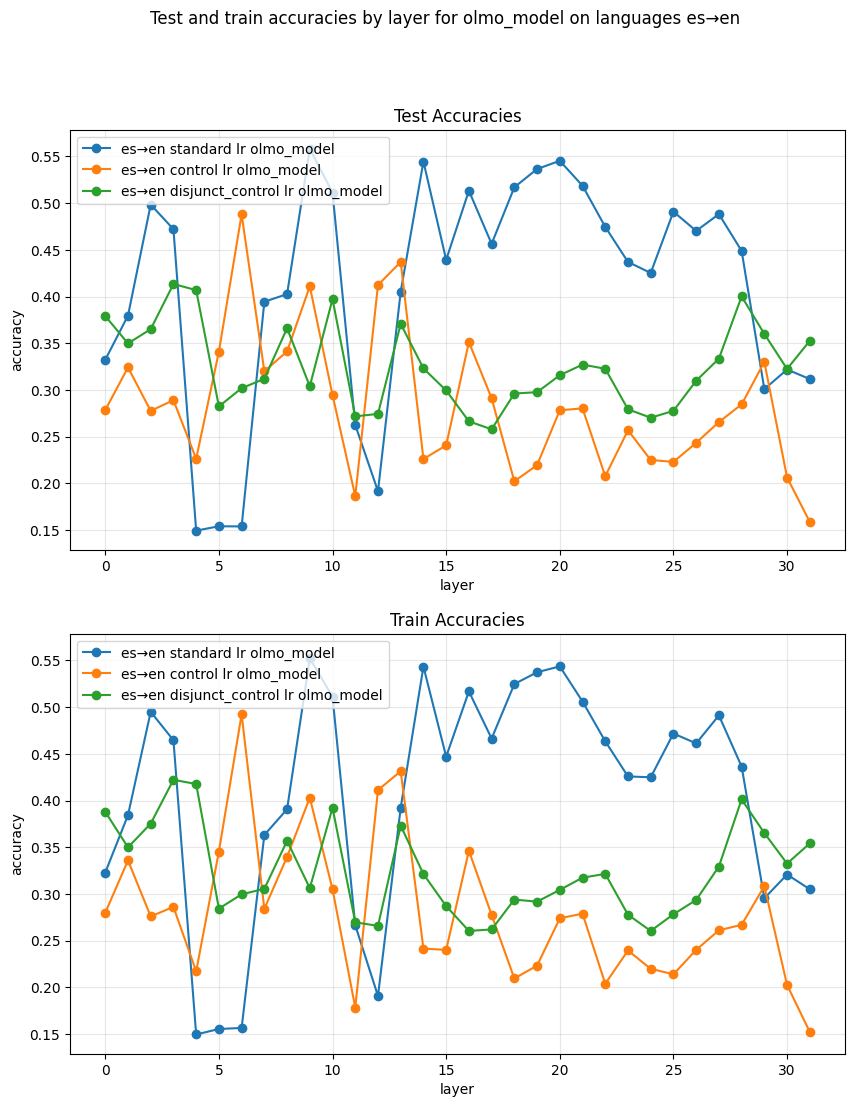

Plot saved to plots\Test_and_train_accuracies_by_layer_for_tiny_aya_global_on_languages_en→es.png


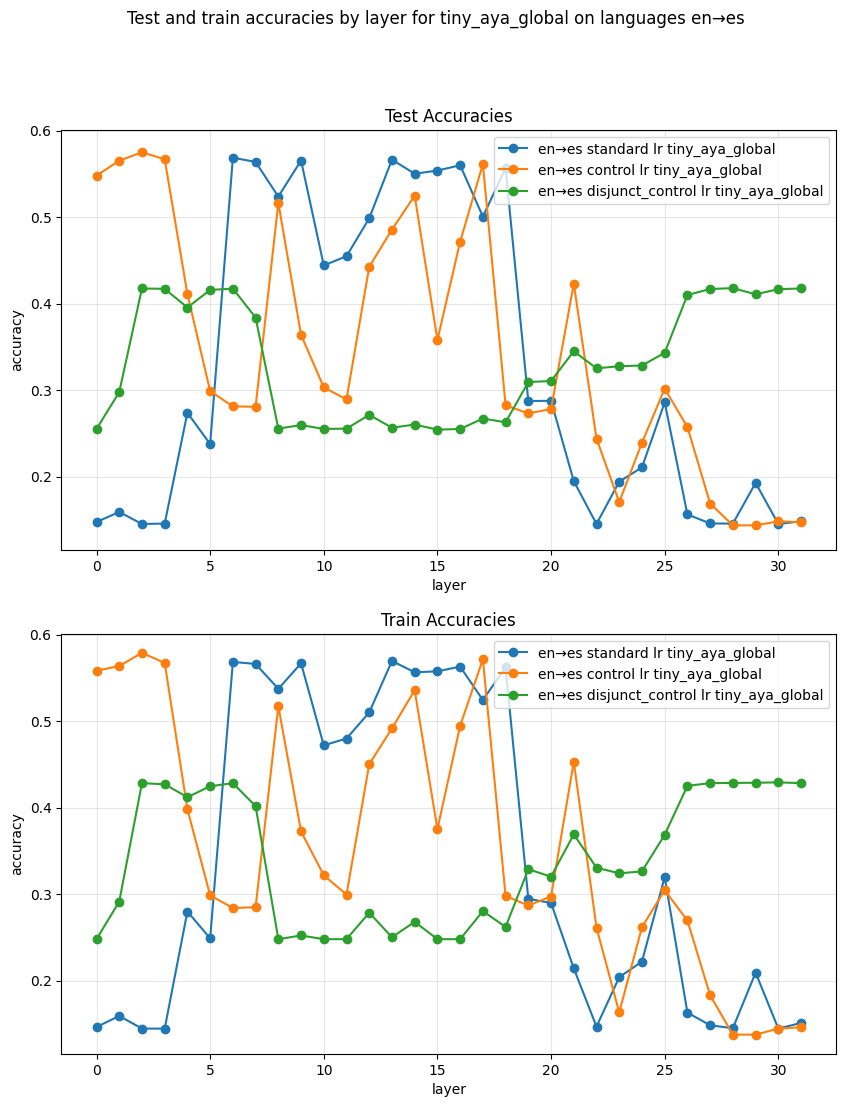

Plot saved to plots\Test_and_train_accuracies_by_layer_for_tiny_aya_global_on_languages_es→en.png


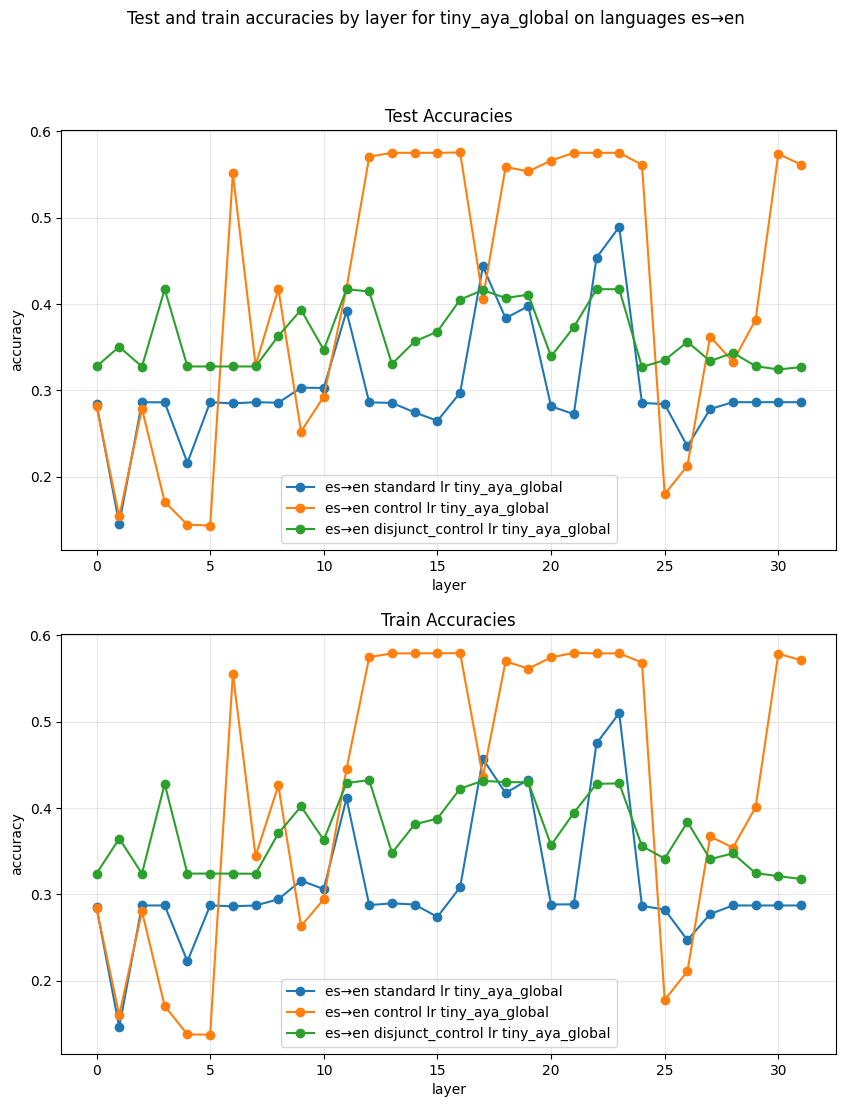

In [ ]:
experiment_number = 2

model_names: list[str] = MODEL_NAMES
language_pairs: list[tuple[str, str]] = list(permutations(LANGUAGES, 2))
probing_tasks: list[str] = PROBING_TASKS
probe_type: str = "lr"

custom = False
if custom:
    model_names = ["olmo_model"]
    language_pairs = [("es", "en")]
    probing_tasks = ["standard"]
    probe_type = "lr"
    print(f"Using custom configuration")
    ic(model_names, language_pairs, probing_tasks, probe_type)
else:
    print(f"Using default settings")

force_probe_creation: bool = False
run_experiment: bool = False

ic(force_probe_creation, run_experiment)

# If run_experiment, run the experiment and save the results as files.
if run_experiment:
    run_experiment_2(language_pairs, probing_tasks, probe_type, model_names, force_probe_creation)

# Load the results from files
experiment_results_per_language: dict[str, list[ExperimentResult]] = {}

for model_name in model_names:
    for language_a, language_b in language_pairs:
        language_merged_string: str = get_language_merged_string(
            language_a, language_b
        )
        experiment_results_per_language[language_merged_string] = []
        for probing_task in probing_tasks:
            experiment_result: ExperimentResult = ExperimentResult.get_from_file(
                experiment_number,
                language_merged_string,
                probing_task,
                probe_type,
                model_name,
            )
            experiment_results_per_language[language_merged_string].append(
                experiment_result
            )

        # Make some plots
        plot_multiple_metrics(
            experiment_results_per_language[language_merged_string],
            ["test_accuracies", "train_accuracies"],
            f"Test and train accuracies by layer for {model_name} on languages {language_merged_string}",
            "layer",
            "accuracy",
            show=True,
            save=True,
        )